In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings as wr
wr.filterwarnings('ignore')

In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo 
   
covertype = fetch_ucirepo(id=31) # fetch dataset

x = covertype.data.features #features
y = covertype.data.targets  #class

In [4]:
x.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,0
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,0
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,0
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,0
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,0


In [5]:
y.head()

,Cover_Type
0,5
1,5
2,2
3,2
4,5


In [6]:
x.shape

(581012, 54)

In [7]:
y.shape

(581012, 1)

In [8]:
y_new = y.iloc[:,0].to_numpy()

In [9]:
y_new.shape

(581012,)

In [10]:
# train test split
from sklearn.model_selection import train_test_split

In [11]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y_new,test_size=0.30,random_state=42)

In [12]:
# test validation
x_test,x_val,y_test,y_val = train_test_split(xtest,ytest,test_size=0.50,random_state=42)

In [13]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from tqdm import tqdm

In [14]:
dt_model = DecisionTreeClassifier(random_state=42)

In [15]:
dt_model.fit(xtrain,ytrain)

DecisionTreeClassifier(random_state=42)

In [16]:
dt_model.score(xtrain,ytrain)

1.0

In [17]:
# tree.plot_tree(dt_model,filled=True,feature_names=x.columns)

In [18]:
# get ccp alpha values
ccp_values = dt_model.cost_complexity_pruning_path(xtrain,ytrain).ccp_alphas

In [19]:
ccp_values

array([0.00000000e+00, 1.22541749e-06, 1.22610489e-06, ...,
       1.17017988e-02, 5.22224508e-02, 8.70612835e-02])

In [20]:
len(ccp_values)

13618

In [21]:
ccp_values1 = ccp_values[:-1]

In [22]:
ccp_values1

array([0.00000000e+00, 1.22541749e-06, 1.22610489e-06, ...,
       6.37426355e-03, 1.17017988e-02, 5.22224508e-02])

In [23]:
len(ccp_values1)

13617

In [24]:
type(ccp_values1)

numpy.ndarray

In [25]:
reduced_ccp_values1 = ccp_values1[::50]
len(reduced_ccp_values1)

273

In [26]:
clfs_list = []  # save models with diffrent ccp_alpha value
for ccp in tqdm(reduced_ccp_values1,desc="Training Decision Trees with CCP-ALPHA values."):
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp)
    clf.fit(xtrain, ytrain)
    clfs_list.append(clf)

Training Decision Trees with CCP-ALPHA values.: 100%|██████████| 273/273 [43:09<00:00,  9.49s/it]


In [27]:
from joblib import Parallel, delayed

In [28]:
clfs_list

[DecisionTreeClassifier(random_state=42),
 DecisionTreeClassifier(ccp_alpha=1.6244102910703982e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=1.633785625585248e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=1.8440748645219666e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=2.048972071691074e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=2.151420675275628e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=2.1855702098038124e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=2.244960704635437e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=2.2696306024885734e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=2.2948487202940036e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=2.314133163321684e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=2.322168347916551e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=2.3358281617278238e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=2.3470043730279587

In [29]:
train_scores = [ clf.score(xtrain, ytrain) for clf in tqdm(clfs_list,desc="Training Score") ] 
train_scores

Training Score: 100%|██████████| 273/273 [00:53<00:00,  5.10it/s]


[1.0,
 0.9998770616756986,
 0.999749205818425,
 0.999574633397917,
 0.999419731109297,
 0.9992722051201354,
 0.9991713956942081,
 0.9990361635374765,
 0.9988665086499405,
 0.9987116063613206,
 0.998581291737561,
 0.9984534358802876,
 0.9983059098911258,
 0.9981928066327684,
 0.9980477394100927,
 0.9978952958879589,
 0.9977477698987972,
 0.9975830325442332,
 0.997398625057781,
 0.9972412640026751,
 0.9971330782772898,
 0.9969388357248935,
 0.9968134386341061,
 0.9966364074471119,
 0.9964618350266039,
 0.996311850270956,
 0.9961594067488222,
 0.9959922106277722,
 0.9958225557402363,
 0.9956578183856722,
 0.9955225862289406,
 0.9953603076408627,
 0.9952275342506172,
 0.9950750907284833,
 0.9945661260658752,
 0.9945661260658752,
 0.9945661260658752,
 0.994543997167501,
 0.9943399195491606,
 0.9939907747081445,
 0.9937940733892621,
 0.9935481967406592,
 0.993277732427196,
 0.9919204933269078,
 0.9919204933269078,
 0.9919204933269078,
 0.9919204933269078,
 0.9919204933269078,
 0.991920493326

In [30]:
test_scores = [ clf.score(xtest, ytest) for clf in tqdm(clfs_list,desc="Test Score") ] 
test_scores

Test Score: 100%|██████████| 273/273 [00:23<00:00, 11.84it/s]


[0.9341782173673582,
 0.934212639985313,
 0.9342413255002754,
 0.9343675417661098,
 0.934419175693042,
 0.934430649899027,
 0.9344535983109968,
 0.9344134385900495,
 0.9344363870020195,
 0.9344765467229668,
 0.934516706443914,
 0.9344708096199743,
 0.9344765467229668,
 0.9344765467229668,
 0.9345339177528915,
 0.9345683403708464,
 0.9345855516798237,
 0.9346257114007711,
 0.9346486598127409,
 0.9346716082247108,
 0.9346945566366808,
 0.9346773453277033,
 0.9347634018725904,
 0.9348092986965302,
 0.9347920873875528,
 0.9348092986965302,
 0.9348092986965302,
 0.9348035615935377,
 0.9347920873875528,
 0.9348609326234625,
 0.9348265100055076,
 0.9348724068294474,
 0.9348781439324398,
 0.9349814117863043,
 0.9348092986965302,
 0.9348092986965302,
 0.9348092986965302,
 0.9348150357995226,
 0.9349355149623646,
 0.9348838810354323,
 0.9348781439324398,
 0.9349699375803194,
 0.9349355149623646,
 0.9344249127960346,
 0.9344249127960346,
 0.9344249127960346,
 0.9344249127960346,
 0.93442491279603

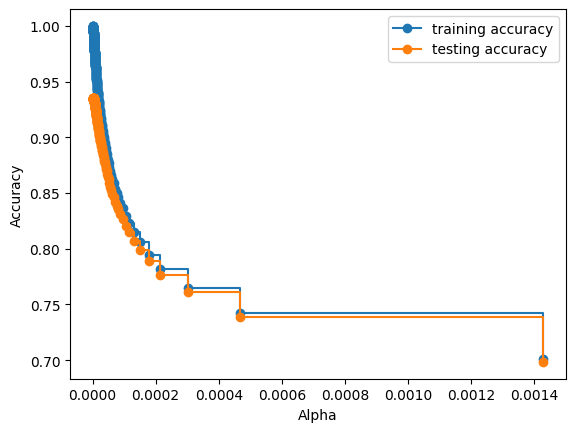

In [31]:
fig, ax = plt.subplots()
ax.set_xlabel("Alpha")
ax.set_ylabel("Accuracy")

ax.plot(reduced_ccp_values1, train_scores, marker='o', label="training accuracy", drawstyle="steps-post")
ax.plot(reduced_ccp_values1, test_scores, marker='o', label="testing accuracy", drawstyle="steps-post")
ax.legend()

In [43]:
meaningful_alphas = [
    ccp_values1[0],
    ccp_values1[100],
    ccp_values1[500],   
    ccp_values1[1000],      
    ccp_values1[2000],        
    ccp_values1[5000],        
    ccp_values1[8000],        
    ccp_values1[10000],       
    ccp_values1[12000],   
    ccp_values1[13000],
    ccp_values1[13600],
    ccp_values1[13610],
    ccp_values1[13613],
    ccp_values1[13615],
    ccp_values1[-1] 
]

In [44]:
ccp_values1[0]

0.0

In [45]:
meaningful_alphas

[0.0,
 1.633785625585248e-06,
 2.314133163321684e-06,
 2.3987965717358927e-06,
 3.097480538721954e-06,
 4.639824078770447e-06,
 8.485154932179505e-06,
 1.3859019429354908e-05,
 3.189793606236206e-05,
 7.680011950920974e-05,
 0.001429079693374108,
 0.004155892215745222,
 0.0057838250416988035,
 0.011701798776791866,
 0.05222245081755511]

In [46]:
clfs_list1 = []  # save models with diffrent ccp_alpha value
for ccp in tqdm(meaningful_alphas,desc="Training Decision Trees with CCP-ALPHA values."):
    clf1 = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp)
    clf1.fit(xtrain, ytrain)
    clfs_list1.append(clf1)

Training Decision Trees with CCP-ALPHA values.: 100%|██████████| 15/15 [02:24<00:00,  9.60s/it]


In [47]:
clfs_list1

[DecisionTreeClassifier(random_state=42),
 DecisionTreeClassifier(ccp_alpha=1.633785625585248e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=2.314133163321684e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=2.3987965717358927e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=3.097480538721954e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=4.639824078770447e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=8.485154932179505e-06, random_state=42),
 DecisionTreeClassifier(ccp_alpha=1.3859019429354908e-05, random_state=42),
 DecisionTreeClassifier(ccp_alpha=3.189793606236206e-05, random_state=42),
 DecisionTreeClassifier(ccp_alpha=7.680011950920974e-05, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.001429079693374108, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.004155892215745222, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.0057838250416988035, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.011701798776791866, ra

In [48]:
train_scores1 = [ clf.score(xtrain, ytrain) for clf in tqdm(clfs_list1,desc="Training Score") ] 
train_scores1

Training Score: 100%|██████████| 15/15 [00:02<00:00,  5.81it/s]


[1.0,
 0.999749205818425,
 0.998581291737561,
 0.9971330782772898,
 0.9937940733892621,
 0.9840057240083795,
 0.9672787356039222,
 0.9467013188823431,
 0.9054112532824533,
 0.849816084266845,
 0.7007164845540289,
 0.6767189236503831,
 0.6730774904845737,
 0.6704687392428966,
 0.6335823244194853]

In [49]:
test_scores1 = [ clf.score(xtest, ytest) for clf in tqdm(clfs_list1,desc="Test Score") ] 
test_scores1

Test Score: 100%|██████████| 15/15 [00:01<00:00, 11.47it/s]


[0.9341782173673582,
 0.9342413255002754,
 0.934516706443914,
 0.9346945566366808,
 0.9348781439324398,
 0.9328185239581421,
 0.927006838626767,
 0.9156014778777308,
 0.886439783366991,
 0.8385923444097668,
 0.6983890214797136,
 0.675951211676152,
 0.6721761979071048,
 0.6694797595006425,
 0.633565494767762]